In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.regressionplots import influence_plot  #cooks distance
import statsmodels.formula.api as smf  # build model
import numpy as np

In [2]:
# read the data
cars = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/Cars.csv')
cars.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [3]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


In [4]:
# checking for na values
cars.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [5]:
# Correlation matrix
# EDA


In [6]:
cars.corr()

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


In [11]:
# Scatter plot between variables along with histograms



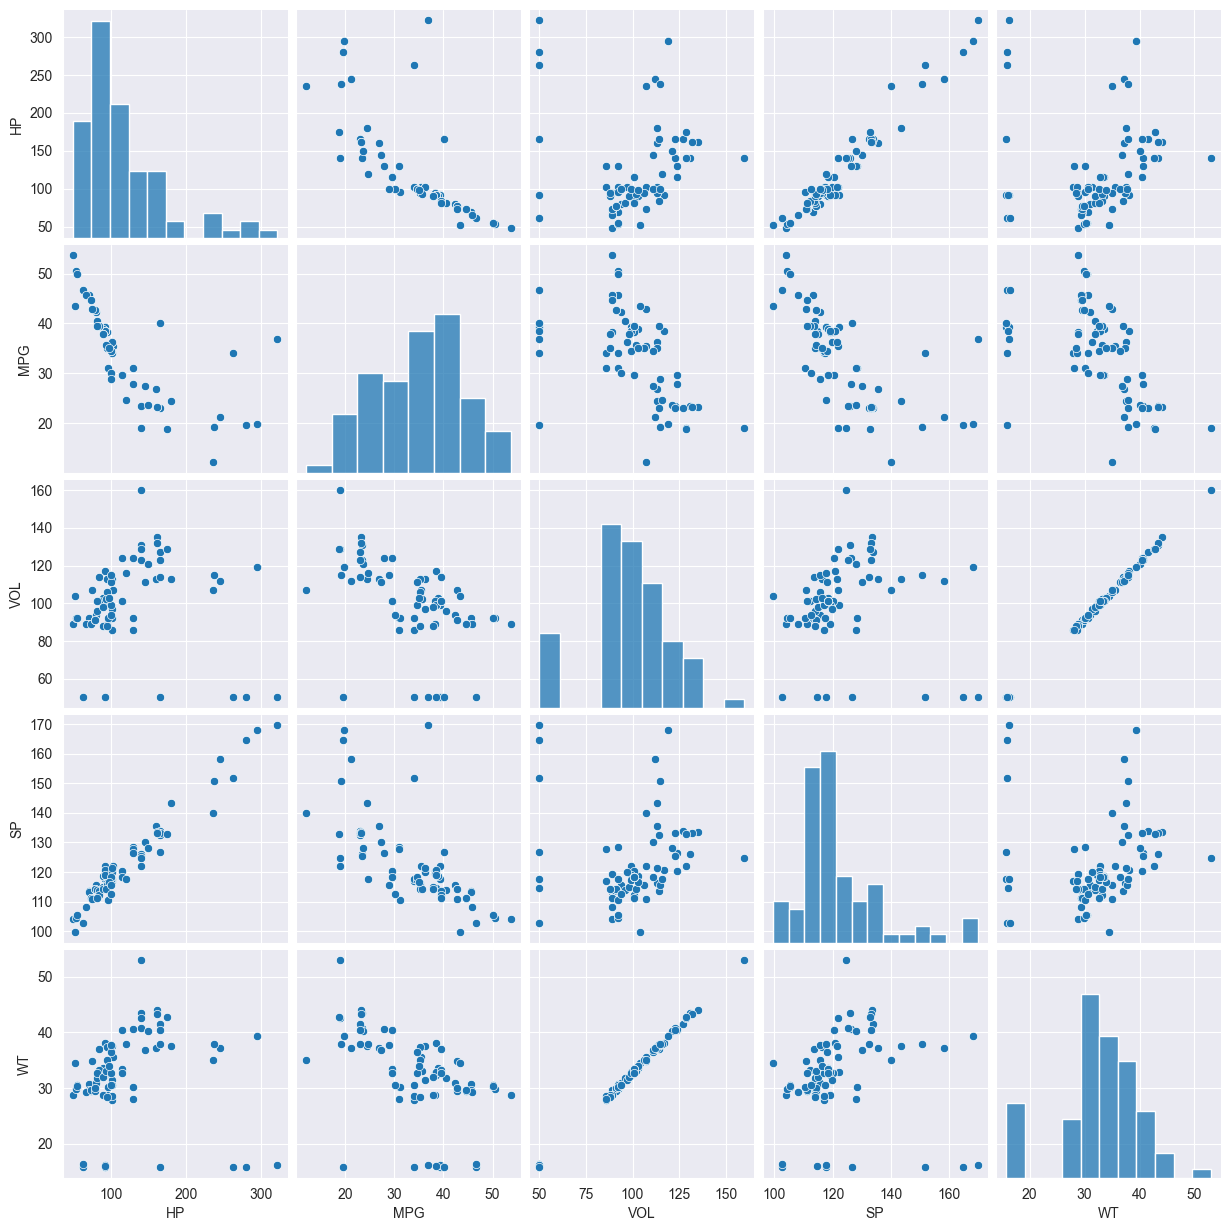

In [13]:
# format the plot background and scatter plots for all the variables
sns.set_style(style = 'darkgrid')
sns.pairplot(cars)

In [15]:
# preparing a model 



In [16]:
# build a model 
import statsmodels.formula.api as smf
model = smf.ols('MPG~WT+VOL+SP+HP',data = cars).fit()

In [17]:
# coefficients
model.params

Intercept    30.677336
WT            0.400574
VOL          -0.336051
SP            0.395627
HP           -0.205444
dtype: float64

In [19]:
# t ans p values
print( model.tvalues , '\n' , model.pvalues)

Intercept    2.058841
WT           0.236541
VOL         -0.590970
SP           2.499880
HP          -5.238735
dtype: float64 
 Intercept    0.042936
WT           0.813649
VOL          0.556294
SP           0.014579
HP           0.000001
dtype: float64


In [20]:
# r squred values adjested r square vlaues
(model.rsquared , model.rsquared_adj)

(np.float64(0.7705372737359842), np.float64(0.7584602881431413))

In [22]:
# simple linear regression models




In [25]:
m1_v = smf.ols('MPG~VOL' , data = cars).fit()
# t and p values 
print( m1_v.tvalues ,'\n', m1_v.pvalues)

Intercept    14.106056
VOL          -5.541400
dtype: float64 
 Intercept    2.753815e-23
VOL          3.822819e-07
dtype: float64


In [26]:
m1_W = smf.ols('MPG~WT' , data = cars).fit()
# t and p values 
print( m1_W.tvalues ,'\n', m1_W.pvalues)

Intercept    14.248923
WT           -5.508067
dtype: float64 
 Intercept    1.550788e-23
WT           4.383467e-07
dtype: float64


In [27]:
m1_Wv = smf.ols('MPG~VOL+WT' , data = cars).fit()
# t and p values 
print( m1_Wv.tvalues ,'\n', m1_Wv.pvalues)

Intercept    12.545736
VOL          -0.709604
WT            0.489876
dtype: float64 
 Intercept    2.141975e-20
VOL          4.800657e-01
WT           6.255966e-01
dtype: float64


In [29]:
# Calculating VIF 




In [31]:
rsq_hp = smf.ols('HP~WT+VOL+SP',data = cars).fit().rsquared
vif_hp = 1/(1-rsq_hp)

rsq_wt = smf.ols('WT~HP+VOL+SP',data = cars).fit().rsquared
vif_wt = 1/(1-rsq_wt)

rsq_vol = smf.ols('VOL~WT+SP+HP',data = cars).fit().rsquared
vif_vol = 1/(1-rsq_vol)

rsq_sp = smf.ols('SP~WT+VOL+HP',data = cars).fit().rsquared
vif_sp = 1/(1-rsq_sp)

#storing vif values in a dataframe
d1 = {'variables' : ['HP','WT','VOL','SP'],'VIF':[vif_hp,vif_wt,vif_vol,vif_sp]}
Vif_frame = pd.DataFrame(d1)
Vif_frame

,variables,VIF
0,HP,19.926589
1,WT,639.533818
2,VOL,638.806084
3,SP,20.007639


In [32]:
# Residual Analysis



In [34]:
# Test for Normaility of Residuals(Q-Q Plot)


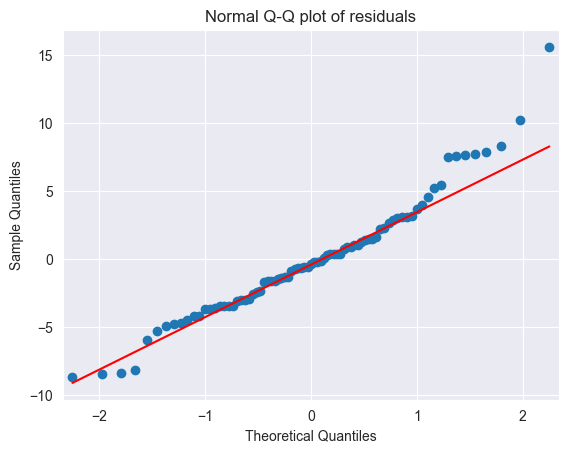

In [36]:
import statsmodels.api as sm
qqplot = sm.qqplot(model.resid,line='q')  # line = 45 to draw the diagonal line
plt.title('Normal Q-Q plot of residuals')
plt.show()

In [109]:
list(np.where(model.resid > 10))

[array([ 0, 76])]

In [38]:
# Residual Plot for Homoscedasticity


In [43]:
# Standardized the dataset 
def get_standardized_values( vals ):
    return (vals - vals.mean()) / vals.std()

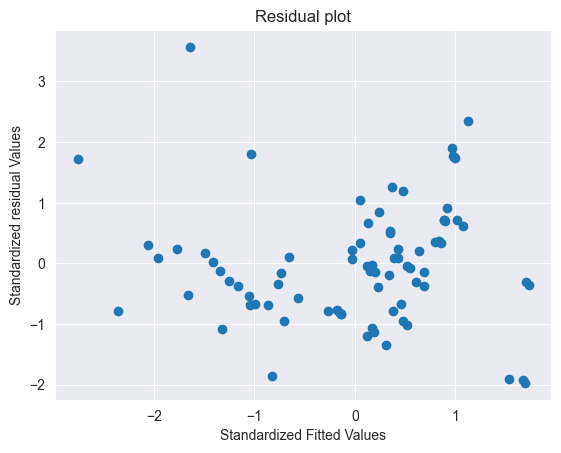

In [44]:
plt.scatter(get_standardized_values(model.fittedvalues),
            get_standardized_values(model.resid))
plt.title('Residual plot')
plt.xlabel('Standardized Fitted Values')
plt.ylabel('Standardized residual Values')
plt.show()

In [45]:
# Residual(ei) vs Regressors(indipendent variable)


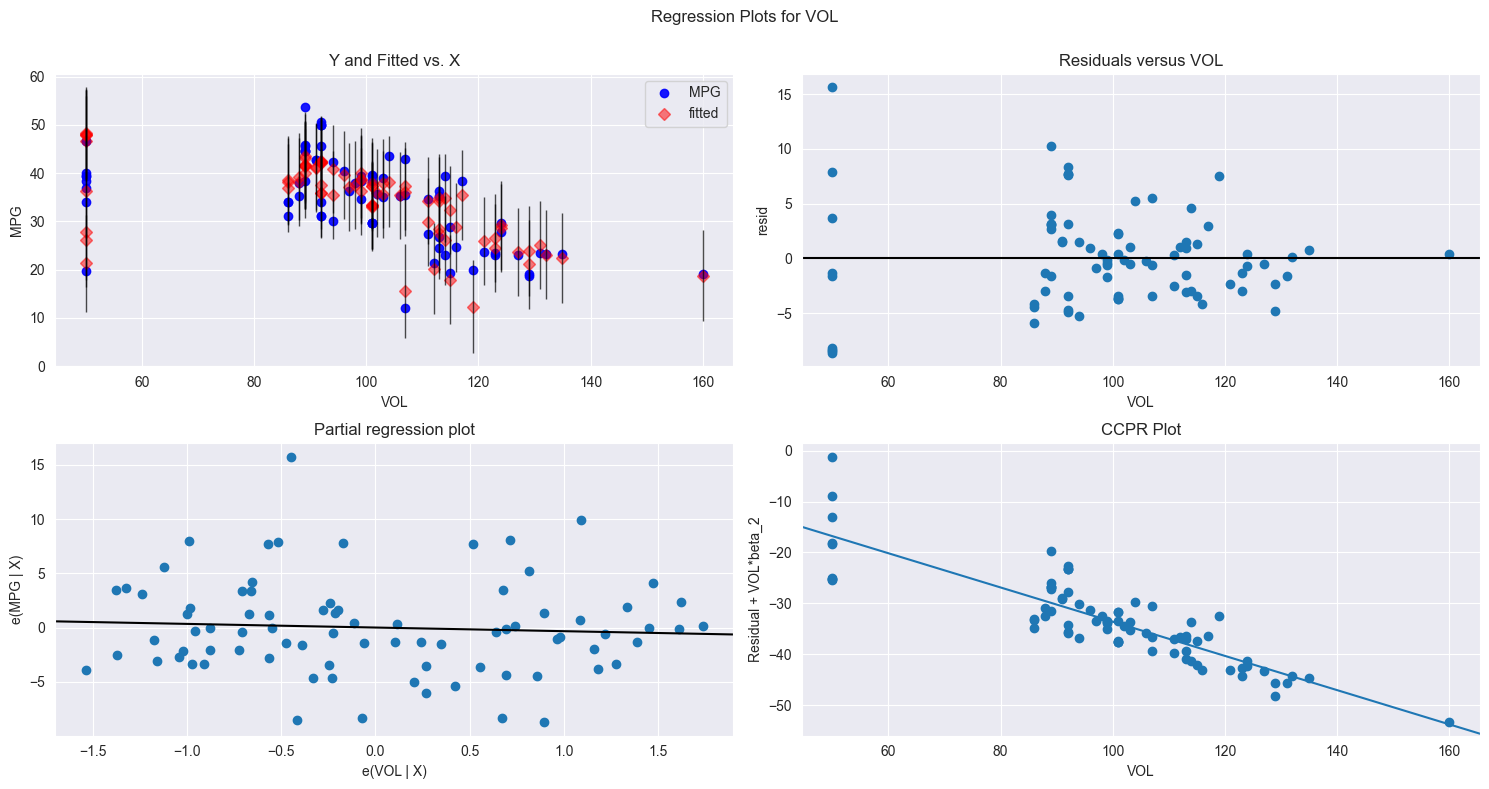

In [46]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'VOL' , fig = fig)
plt.show()

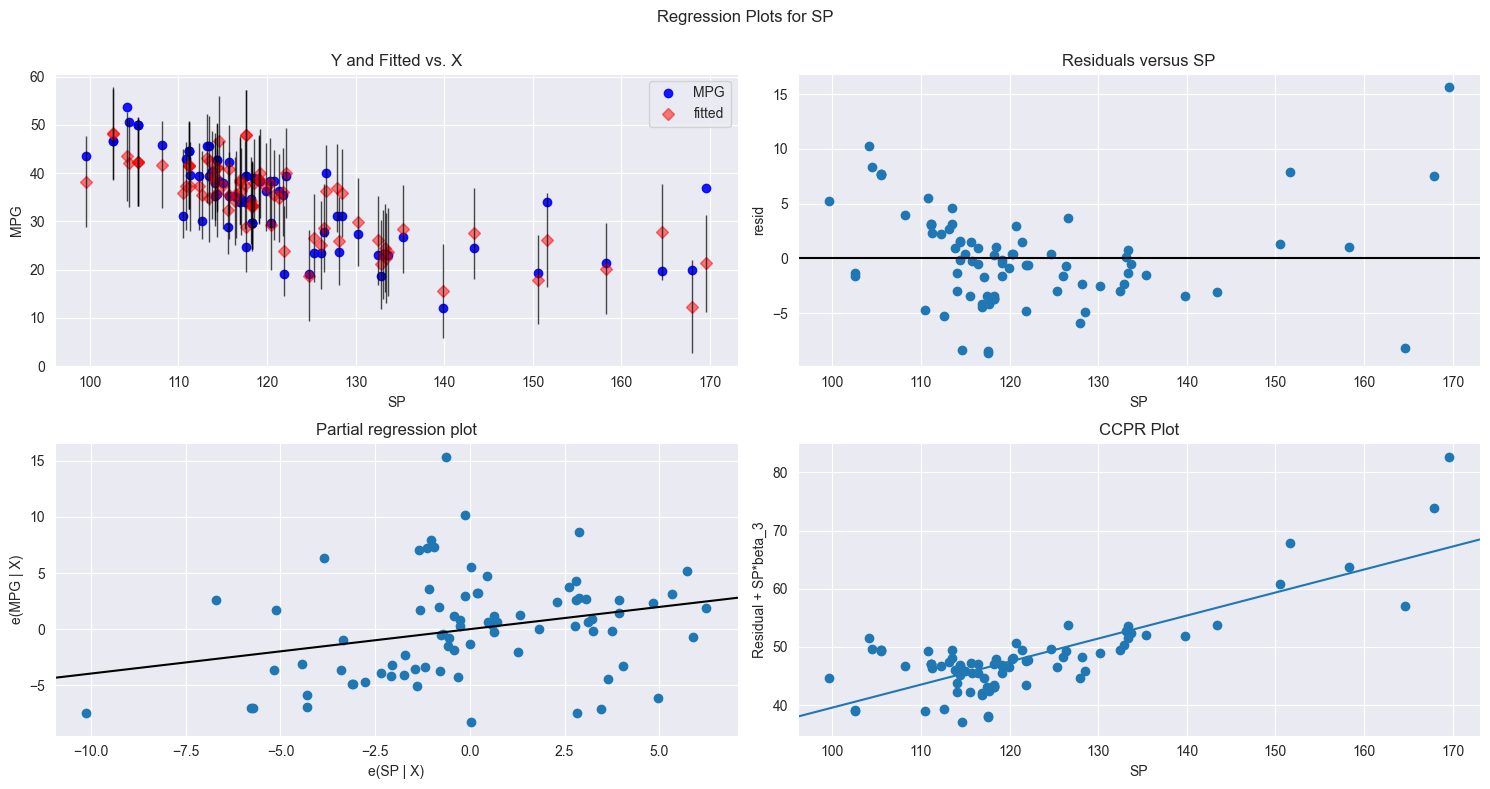

In [47]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'SP' , fig = fig)
plt.show()

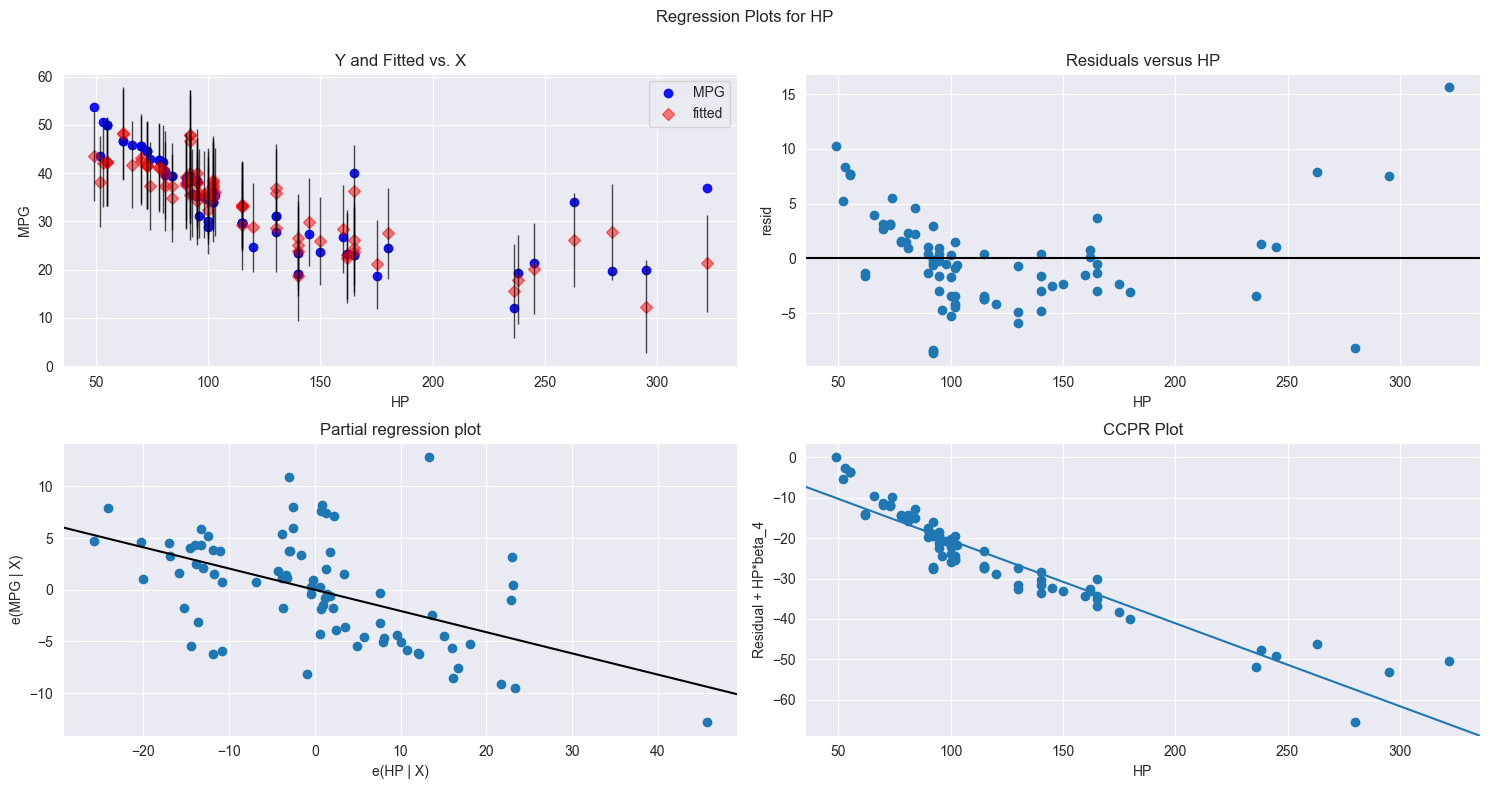

In [48]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'HP' , fig = fig)
plt.show()

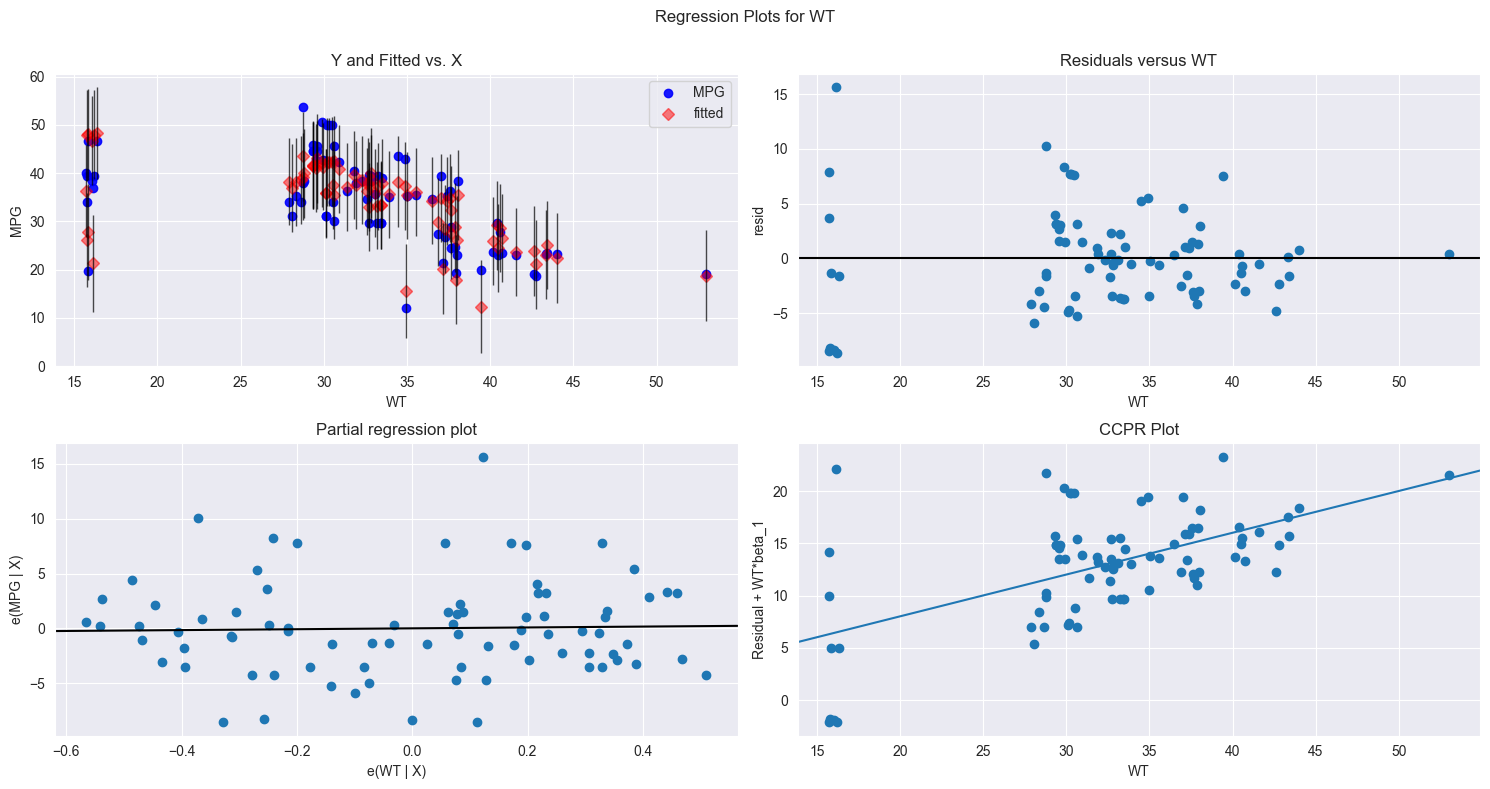

In [49]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'WT' , fig = fig)
plt.show()

In [50]:
# Model Deletion Diagnostics



In [51]:
# Detecting influencers / Outliers

In [52]:
# cook s distance


In [53]:
model_influence = model.get_influence()
(c, _) = model_influence.cooks_distance

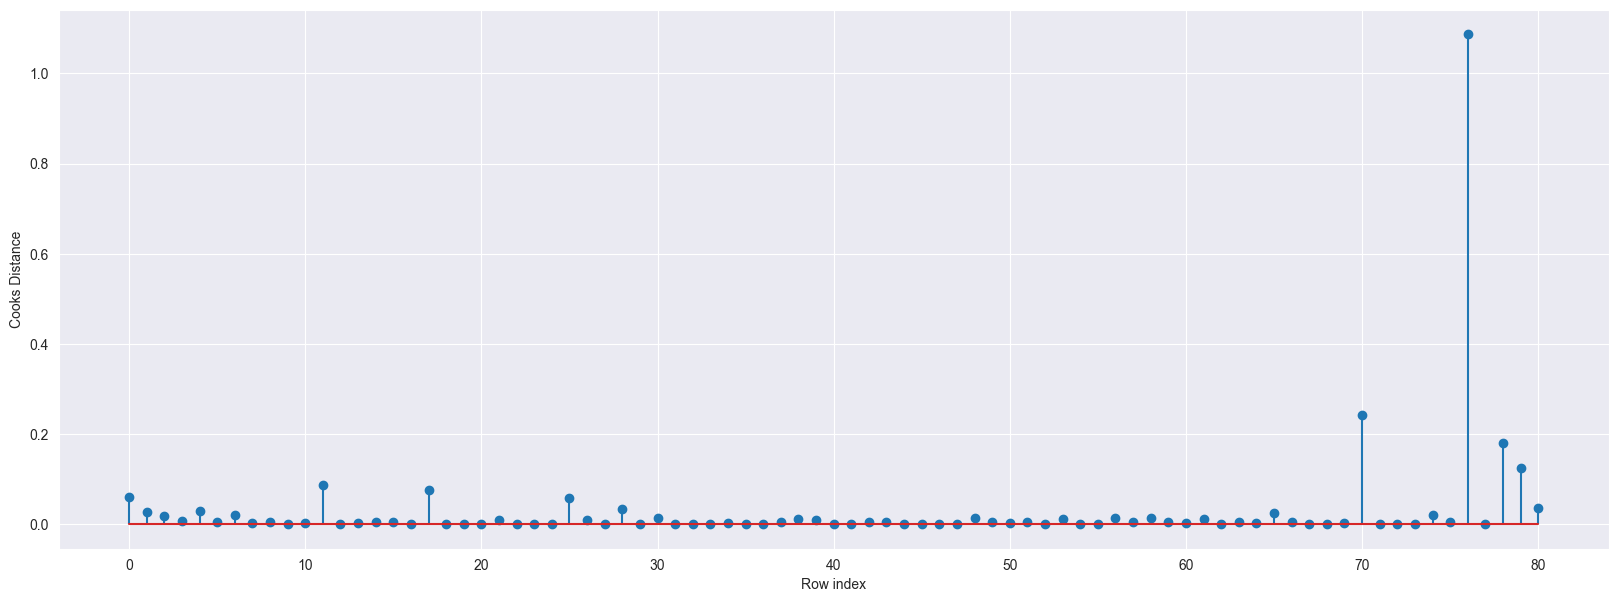

In [55]:
# plot the influencers values using stem plot
fig = plt.subplots(figsize=(20,7))
plt.stem(np.arange(len(cars)),np.round(c,3))
plt.xlabel('Row index')
plt.ylabel('Cooks Distance')
plt.show()

In [56]:
# index ans values of influencers where c is more than .5
(np.argmax(c),np.max(c))

(np.int64(76), np.float64(1.0865193998179885))

In [58]:
# High Influence points



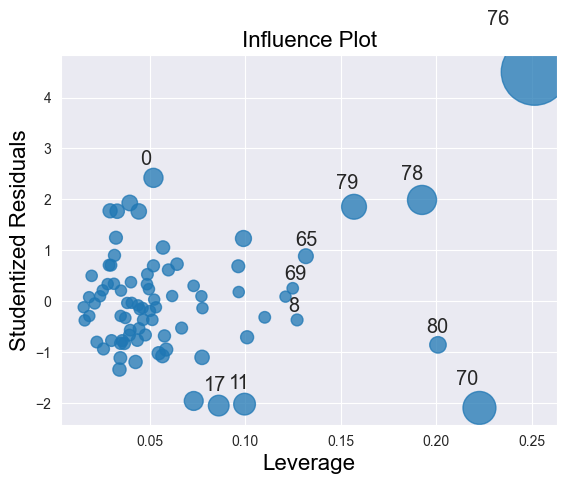

In [59]:
from statsmodels.graphics.regressionplots import influence_plot
influence_plot(model)
plt.show()

In [60]:
k = cars.shape[1]
n = cars.shape[0]
leverage_cutoff = 3 * ((k+1)/n)
leverage_cutoff

0.2222222222222222

In [61]:
# form the above plot it is evident that datapoint 70 and 76 are the influencers


In [62]:
cars[cars.index.isin([70,76])]

,HP,MPG,VOL,SP,WT
70,280,19.678507,50,164.598513,15.823060
76,322,36.900000,50,169.598513,16.132947


In [63]:
# see the dif in hp and other variables values
cars.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [64]:
# improving the model 



In [65]:
# load the data
cars_new = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/Cars.csv')

In [73]:
# discard the datapoints which are influential and resign the row numbers(reset_index())
car1 = cars_new.drop(cars_new.index[[70,76]],axis=0).reset_index()

In [74]:
# drop the original index
car1 = car1.drop(['index'],axis=1)

In [75]:
car1

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113
76,263,34.000000,50,151.598513,15.769625
77,295,19.833733,119,167.944460,39.423099


In [69]:
# Build Model



In [80]:
# Exclude variables 'WT' and generate R-squared and ATC values
final_m1_V = smf.ols('MPG~VOL+SP+HP',data =car1).fit()

In [81]:
(final_m1_V .rsquared , final_m1_V.aic)

(np.float64(0.8161692010376007), np.float64(446.11722639447726))

In [82]:
# Exclude variables 'VOL' and generate R-squared and ATC values
final_m1_W = smf.ols('MPG~WT+SP+HP',data =car1).fit()

In [83]:
(final_m1_W .rsquared , final_m1_W.aic)

(np.float64(0.8160034320495304), np.float64(446.1884323575031))

In [84]:
# comparing above R-squared and AIC vlaues , model 'final_m1_V' has high R-squred and low AIC values hence include variable 'VOL' so that
# multicollinearity problem would be resolved

In [86]:
# COOKs distance



In [87]:
model_influence_V = final_m1_V.get_influence()
(c_V,_) = model_influence_V.cooks_distance

Text(0, 0.5, 'Cooks Distance')

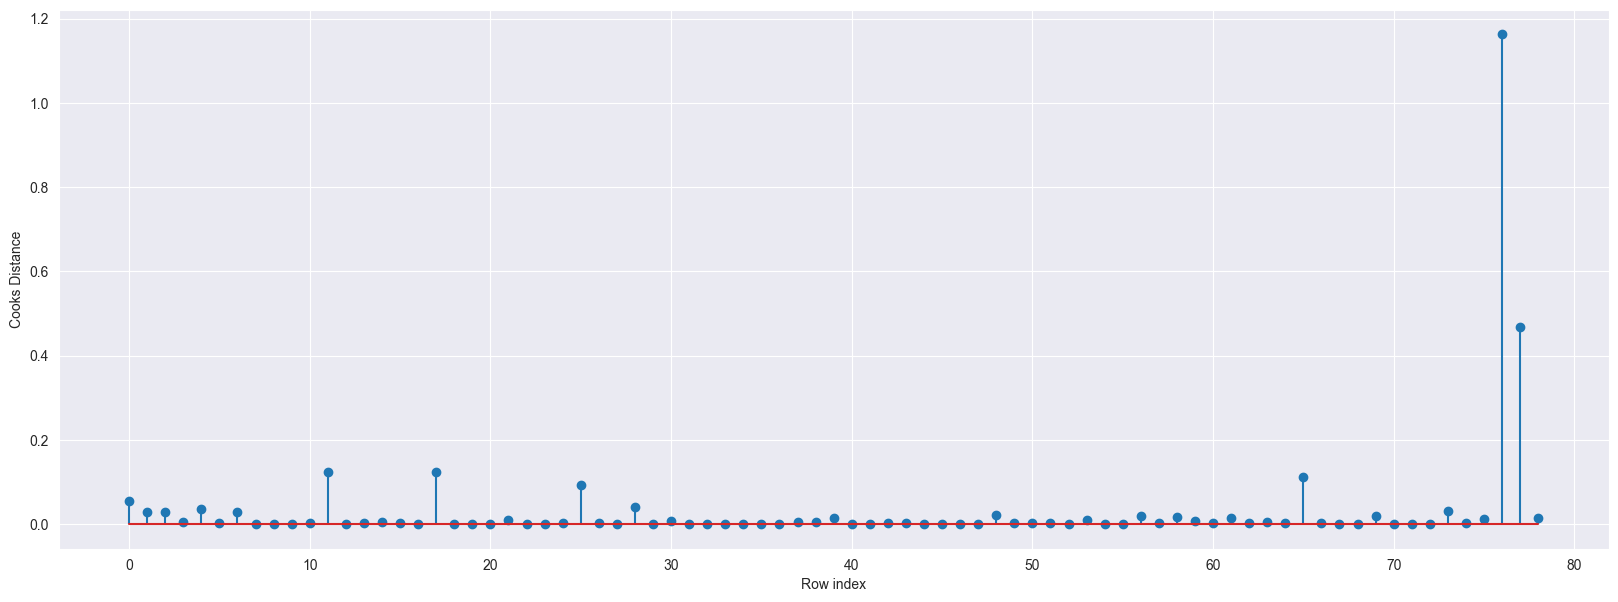

In [89]:
fig = plt.subplots(figsize = (20,7))
plt.stem(np.arange(len(car1)),np.round(c_V,3))
plt.xlabel('Row index')
plt.ylabel('Cooks Distance')

In [90]:
# index of the data points where c is more than .5
(np.argmax(c_V),np.max(c_V))

(np.int64(76), np.float64(1.1629387469135142))

In [95]:
# drop 76 and 77 observations
car2 = car1.drop(car1.index[[76,77]],axis =0).reset_index()
car2 = car2.drop(['index'],axis=1)

In [96]:
car2

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
72,140,19.086341,160,124.715241,52.997752
73,140,19.086341,129,121.864163,42.618698
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113


In [97]:
# build the model on the new data car2
final_m1_V = smf.ols('MPG~VOL+SP+HP',data = car2).fit()

In [98]:
# again check for influencers
model_influence_V = final_m1_V.get_influence()
(c_V,_) = model_influence_V.cooks_distance

Text(0, 0.5, 'Cooks Distance')

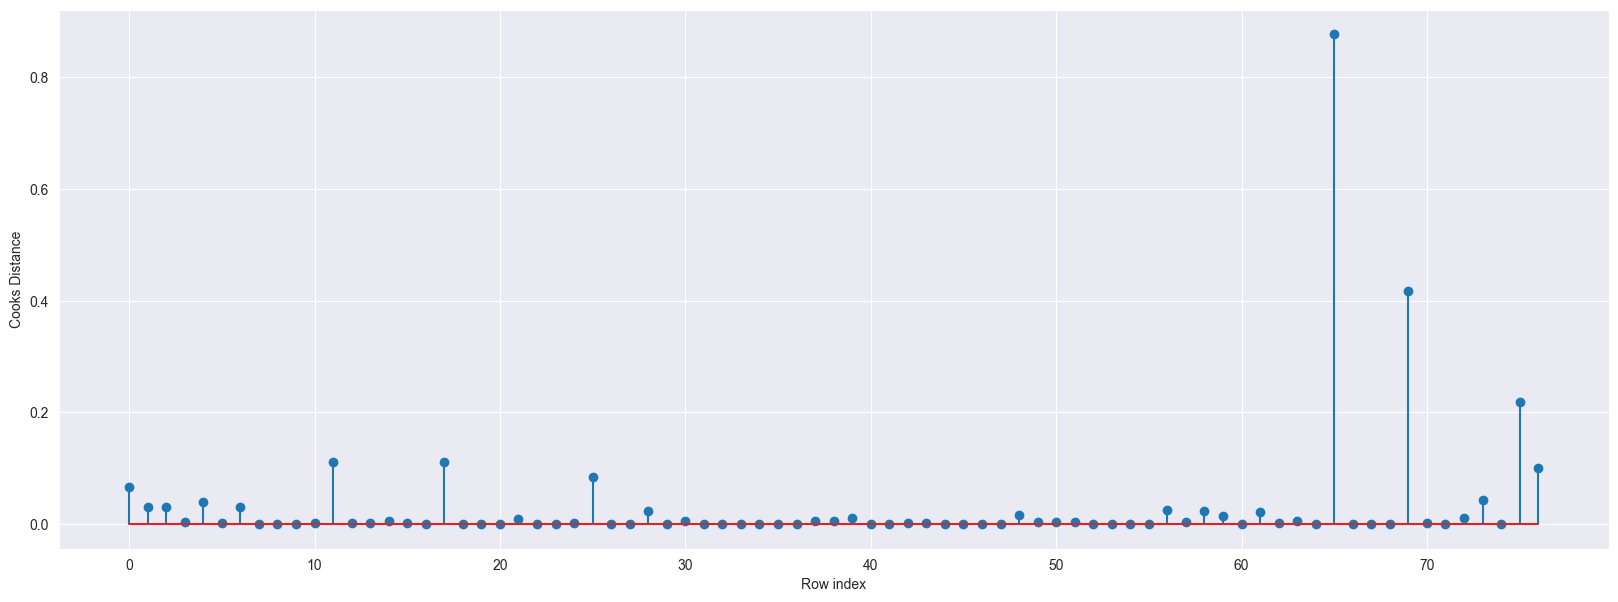

In [100]:
fig = plt.subplots(figsize = (20,7))
plt.stem(np.arange(len(car2)),np.round(c_V,3))
plt.xlabel('Row index')
plt.ylabel('Cooks Distance')
# check for the points more than 1

In [101]:
# index of the data points where c is more than .5
(np.argmax(c_V),np.max(c_V))

(np.int64(65), np.float64(0.8774556986296818))

In [102]:
# since the value is <1 we can stop the model diagnostic process and finalize the model



In [103]:
# check the accuracy of the model
final_m1_V = smf.ols('MPG~VOL+SP+HP' ,data = car2).fit()

In [104]:
(final_m1_V.rsquared,final_m1_V.aic)

(np.float64(0.8669636111859063), np.float64(409.4153062719508))

In [105]:
# predicting the new data



In [106]:
# new data for prediction
new_data = pd.DataFrame({'HP':40 , 'VOL':95,'SP':102,'WT':35},index =[1])

In [107]:
new_data

,HP,VOL,SP,WT
1,40,95,102,35


In [108]:
final_m1_V.predict(new_data)

1    46.035594
dtype: float64